# Statistical Customer Segmentation System

## Notebook 03: Feature Engineering (RFM Analysis)

### Purpose

This notebook transforms transaction-level data into customer-level behavioral features.

### Objectives

- Create Recency features
- Create Frequency features
- Create Monetary features
- Construct the RFM dataset
- Explore customer behavior patterns

### Expected Outcome

A customer-level dataset suitable for dimensionality reduction, clustering, and segmentation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

os.makedirs("images", exist_ok=True)

In [2]:
df = pd.read_csv(
    "/content/cleaned_online_retail.csv"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Date Preparation

Recency calculations require proper datetime formatting.

In [3]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

df["InvoiceDate"].head()

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


In [4]:
print(
    "Latest Transaction Date:"
)

print(
    df["InvoiceDate"].max()
)

Latest Transaction Date:
2011-01-12 16:14:00


## Create Reference Date

Recency measures the number of days since a customer's most recent purchase.

In [5]:
snapshot_date = (
    df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

snapshot_date

Timestamp('2011-01-13 16:14:00')

## RFM Feature Construction

In [6]:
rfm = (
    df.groupby("CustomerID")
      .agg(
          {
              "InvoiceDate":
              lambda x:
              (
                  snapshot_date
                  - x.max()
              ).days,

              "InvoiceNo":
              "nunique",

              "Sales":
              "sum"
          }
      )
)

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,37,1,711.79
12348.0,27,1,892.80
12359.0,1,1,547.50
12370.0,27,2,1864.27
12377.0,24,1,1001.52


In [7]:
rfm.describe()

,Recency,Frequency,Monetary
count,1104.000000,1104.000000,1104.000000
mean,24.298007,2.307971,865.032228
std,14.082742,12.161399,6361.916853
min,1.000000,1.000000,-1192.200000
25%,8.000000,1.000000,173.297500
50%,28.500000,1.000000,318.620000
75%,36.000000,2.000000,606.340000
max,43.000000,399.000000,204223.960000


## RFM Overview

The RFM table summarizes customer purchasing behavior using three core dimensions:

- Recency
- Frequency
- Monetary Value

In [8]:
print(
    "Number of Customers:"
)

print(
    rfm.shape[0]
)

Number of Customers:
1104


In [9]:
rfm.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0


## Recency Distribution

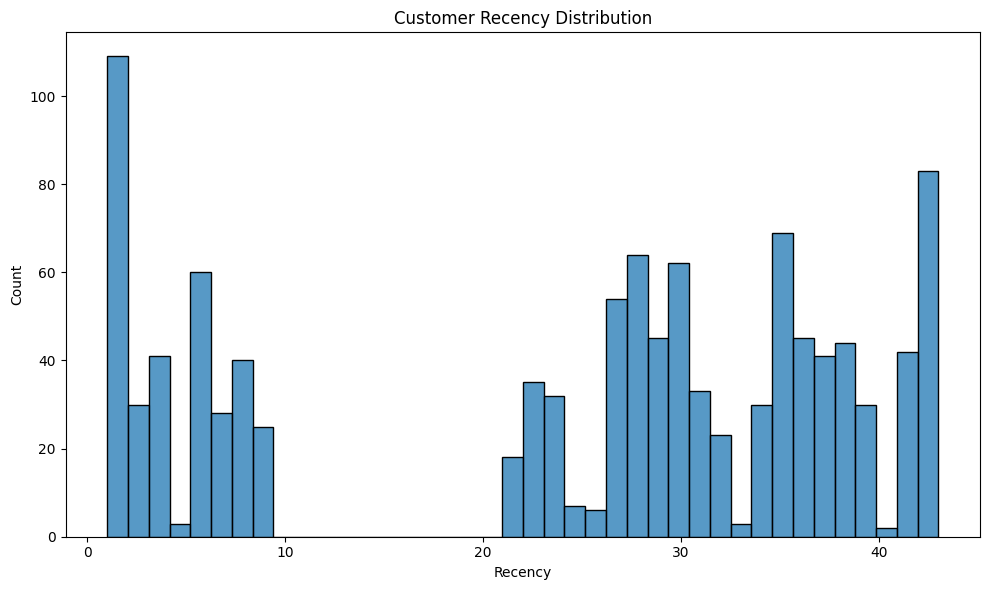

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    rfm["Recency"],
    bins=40
)

plt.title(
    "Customer Recency Distribution"
)

plt.tight_layout()

plt.savefig(
    "images/recency_distribution.png",
    dpi=300
)

plt.show()

## Frequency Distribution

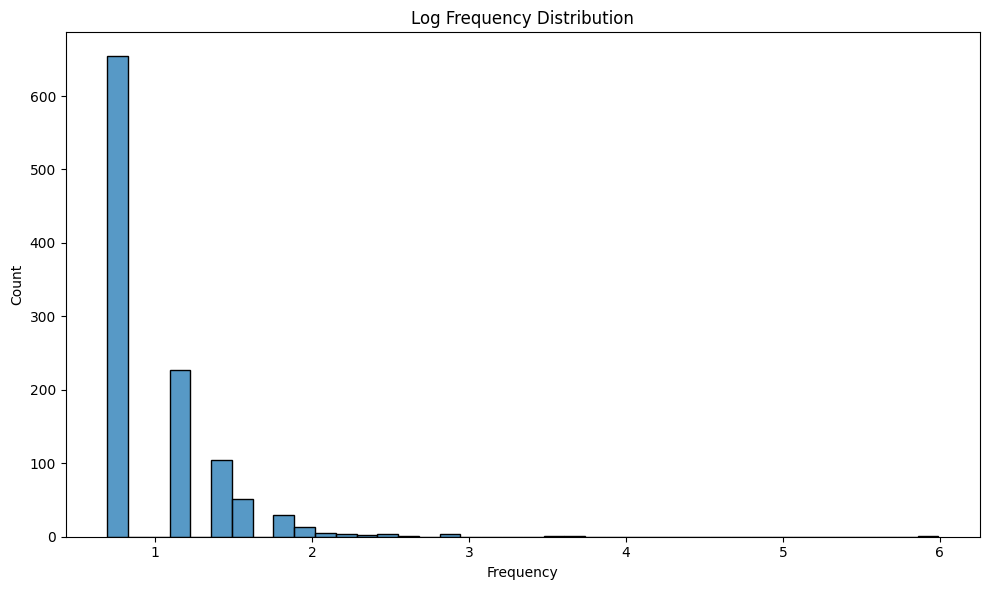

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(
        rfm["Frequency"]
    ),
    bins=40
)

plt.title(
    "Log Frequency Distribution"
)

plt.tight_layout()

plt.savefig(
    "images/frequency_distribution.png",
    dpi=300
)

plt.show()

## Monetary Distribution

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


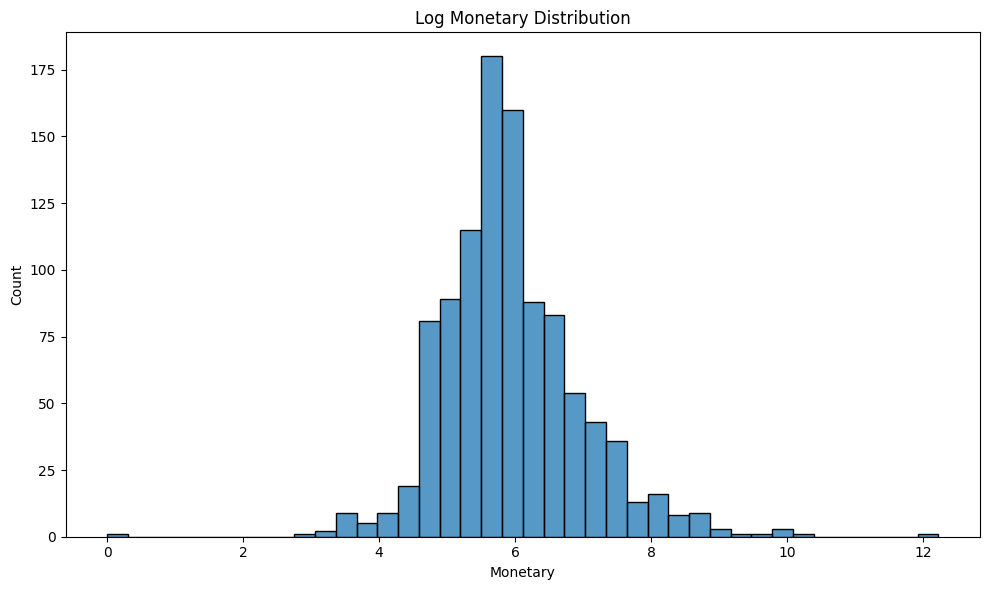

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(
        rfm["Monetary"]
    ),
    bins=40
)

plt.title(
    "Log Monetary Distribution"
)

plt.tight_layout()

plt.savefig(
    "images/monetary_distribution.png",
    dpi=300
)

plt.show()

## Correlation Among RFM Variables

In [14]:
corr_matrix = (
    rfm.corr()
)

corr_matrix

,Recency,Frequency,Monetary
Recency,1.000000,-0.098532,-0.103493
Frequency,-0.098532,1.000000,0.966799
Monetary,-0.103493,0.966799,1.000000


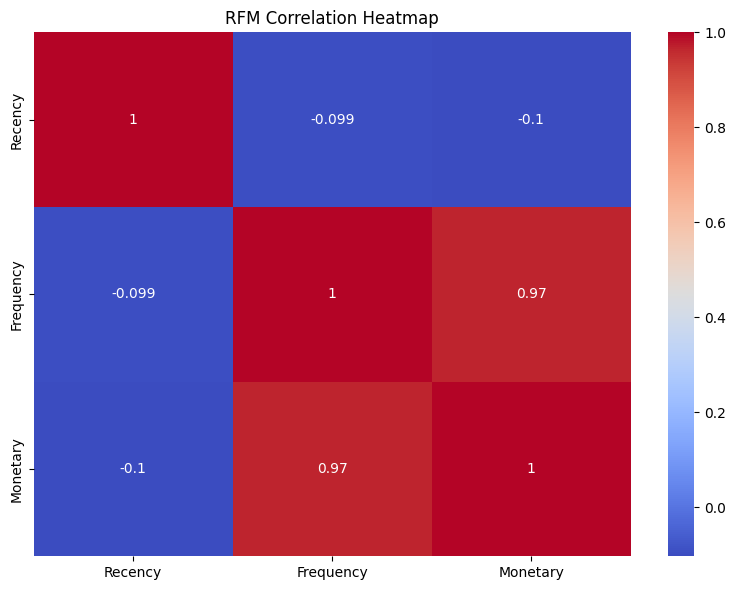

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "RFM Correlation Heatmap"
)

plt.tight_layout()

plt.savefig(
    "images/rfm_correlation_heatmap.png",
    dpi=300
)

plt.show()

## Highest Value Customers

In [16]:
rfm.sort_values(
    by="Monetary",
    ascending=False
).head(10)

,Recency,Frequency,Monetary
CustomerID,,,
15287.0,1,399,204223.96
18102.0,35,4,27834.61
15749.0,2,2,22998.40
15061.0,1,17,21264.71
17450.0,2,5,20649.04
16029.0,9,8,13112.52
17511.0,8,6,10459.30
14646.0,23,2,8591.88
13089.0,7,13,7618.67


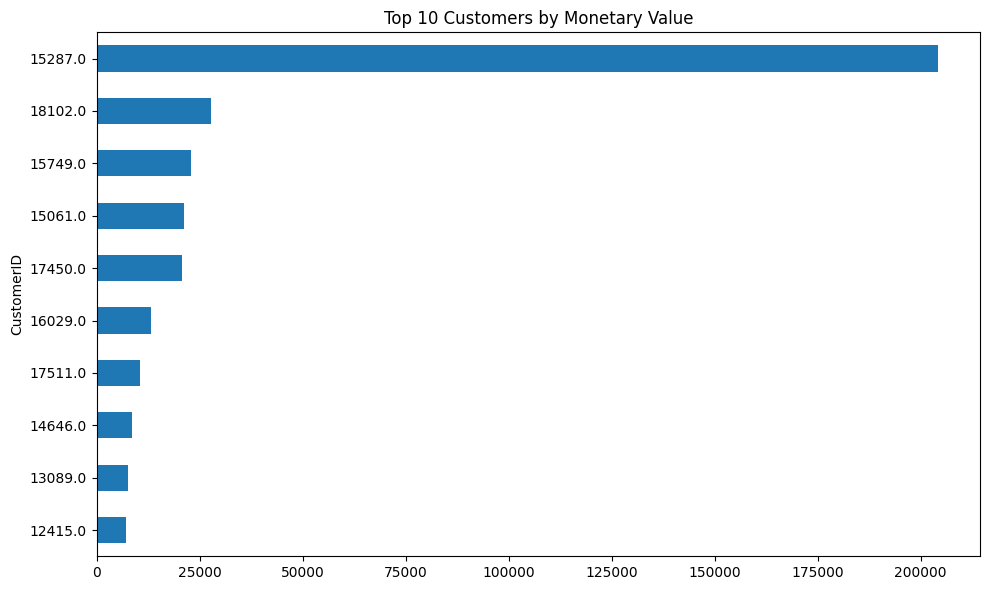

In [17]:
plt.figure(figsize=(10,6))

rfm.sort_values(
    by="Monetary",
    ascending=False
).head(10)["Monetary"].sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 10 Customers by Monetary Value"
)

plt.tight_layout()

plt.savefig(
    "images/top_customers_monetary.png",
    dpi=300
)

plt.show()

In [18]:
rfm.to_csv(
    "rfm_dataset.csv"
)

print(
    "RFM dataset saved successfully."
)

RFM dataset saved successfully.


## Findings

The RFM framework successfully transformed transaction-level records into customer-level behavioral metrics.

Key observations include:

- Significant variation in customer recency
- Strong concentration of purchasing frequency
- Highly skewed spending behavior
- Evidence of substantial customer heterogeneity

These findings motivate the application of PCA and clustering methods in subsequent analyses.